# ETAPA 1 — Criar dataset

## Cenário:

##### Uma academia mudou o layout e quer saber se melhorou a satisfação.

## Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np

## Gerando dados que seguem a distribuição normal

In [2]:
np.random.seed(42)

# Antes da mudança
antes = np.random.normal(loc=7.0, scale=1.5, size=100)

# Depois da mudança
depois = np.random.normal(loc=7.5, scale=1.5, size=100)

df_satisfacao = pd.DataFrame({
    'satisfacao_antes': antes,
    'satisfacao_depois': depois
})

df_satisfacao.head()

,satisfacao_antes,satisfacao_depois
0,7.745071,5.376944
1,6.792604,6.869032
2,7.971533,6.985928
3,9.284545,6.296584
4,6.648770,7.258071


#### Aqui simulamos um problema real criando base para um teste estatístico

# ETAPA 2 — Limpeza de dados

## Verificando os dados

In [3]:
df_satisfacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   satisfacao_antes   100 non-null    float64
 1   satisfacao_depois  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [4]:
df_satisfacao.describe()

,satisfacao_antes,satisfacao_depois
count,100.000000,100.000000
mean,6.844230,7.533457
std,1.362253,1.430503
min,3.070382,4.621843
25%,6.098641,6.291509
50%,6.809566,7.626161
75%,7.608928,8.307256
max,9.778417,11.580254


### Como os valores de satisfação devem ficar entre 0 e 10, devemos tratar os valores inválidos

In [5]:
df_satisfacao = df_satisfacao.clip(lower=0, upper=10)

# ETAPA 3 — Análise exploratória (EDA)

## Importando as libs

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

## Histogramas

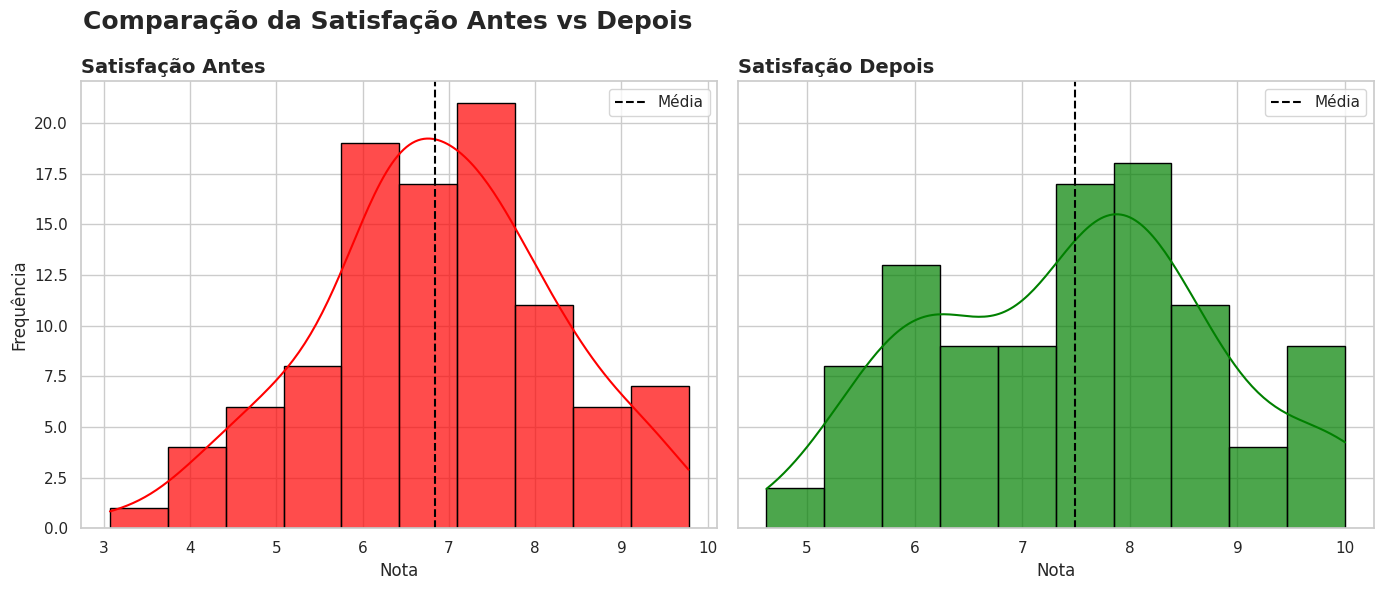

In [7]:
sns.set_theme(style='whitegrid')

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.histplot(df_satisfacao['satisfacao_antes'], kde=True, ax=axs[0], color='red', bins=10, edgecolor='black', alpha=0.7)
axs[0].set_title("Satisfação Antes", fontsize=14, fontweight='bold', loc='left')
axs[0].set_xlabel("Nota")
axs[0].set_ylabel("Frequência", fontsize=12)
axs[0].axvline(df_satisfacao['satisfacao_antes'].mean(), color='black', linestyle='--', label='Média')
axs[0].legend()

sns.histplot(df_satisfacao['satisfacao_depois'], kde=True, ax=axs[1], color='green', bins=10, edgecolor='black', alpha=0.7)
axs[1].set_title("Satisfação Depois", fontsize=14, fontweight='bold', loc='left')
axs[1].set_xlabel("Nota", fontsize=12)
axs[1].axvline(df_satisfacao['satisfacao_depois'].mean(), color='black', linestyle='--', label='Média')
axs[1].legend()

plt.suptitle("Comparação da Satisfação Antes vs Depois", fontsize=18, fontweight='bold', ha='right')
plt.tight_layout()
plt.show()

##### Percebe-se pouca diferença visual com os dois gráficos seguindo a distribuição normal, porém há claramente um aumento na média.

## Boxplot

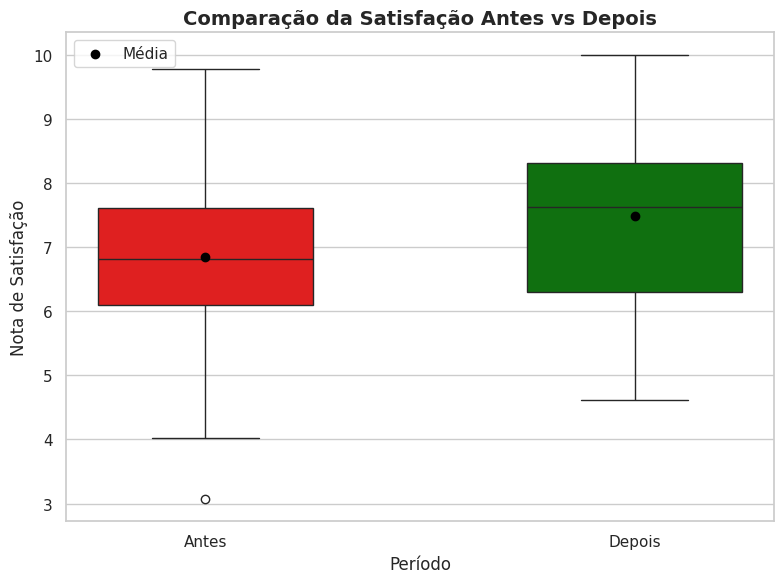

In [8]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df_satisfacao[['satisfacao_antes', 'satisfacao_depois']], palette=['red', 'green'], width=0.5)

plt.title("Comparação da Satisfação Antes vs Depois", fontsize=14, fontweight='bold')
plt.xlabel("Período")
plt.ylabel("Nota de Satisfação")
plt.xticks([0, 1], ["Antes", "Depois"])

for i, col in enumerate(['satisfacao_antes', 'satisfacao_depois']):
    mean = df_satisfacao[col].mean()
    plt.scatter(i, mean, color='black', zorder=3, label='Média' if i == 0 else "")

plt.legend()

plt.tight_layout()
plt.show()

##### Segundo o gráfico, tanto a média quanto a mediana cresceram em comparação de antes e depois, porém precisamos de testes mais avançados para termos certeza se realmente houve um aumento na satisfação.

# ETAPA 4 — Teste de Hipótese

## Hipóteses

##### H0: Satisfação antes = satisfação depois
##### H1: Satisfação antes != satisfação depois

## Teste de normalidade

In [13]:
from scipy.stats import shapiro

stat, p = shapiro(df_satisfacao['satisfacao_depois'] - df_satisfacao['satisfacao_antes'])

print(f"P-valor normalidade: {p}")

P-valor normalidade: 0.3412098495812089


##### Como o p é maior que 0.05, garantimos a normalidade.

## Teste t pareado

##### Foi escolhido o teste t pareado, pois os dados são dependentes e seguem a distribuição normal.

In [9]:
from scipy.stats import ttest_rel

stat, p_value = ttest_rel(df_satisfacao['satisfacao_depois'], df_satisfacao['satisfacao_antes'], alternative='two-sided')

print(f"Estatística: {stat}")
print(f"P-valor: {p_value}")

Estatística: 3.208306452871077
P-valor: 0.001799459938232452


##### O p-valor representa a probabilidade de observarmos um resultado tão extremo quanto o obtido (ou mais), assumindo que a hipótese nula seja verdadeira, de acordo com o teste existe uma chance de aproximadamente 0.17% desse cenário acontecer considerando a hipótese nula, o que uma chance baixissima.

## Interpretação

Testaremos o caso com um nível de confiança de 95%, logo o alpha será de 0.05 (1 - confianca).

In [10]:
alpha = 0.05

if p_value < alpha:
    print("Rejeitamos H0 → Existe diferença significativa")
else:
    print("Não rejeitamos H0 → Não há evidência suficiente")

Rejeitamos H0 → Existe diferença significativa


##### Como a chance de no cenário que estamos, H0 acontecer, nós o rejeitamos e concluímos que existe uma diferença significativa.

##### Apesar da diferença ser estatisticamente significativa, avaliamos também o tamanho do efeito para entender seu impacto prático.

In [12]:
mean_diff = df_satisfacao['satisfacao_depois'].mean() - df_satisfacao['satisfacao_antes'].mean()
print(f"Diferença média: {mean_diff:.2f}")

Diferença média: 0.64


In [14]:
import numpy as np

diff = df_satisfacao['satisfacao_depois'] - df_satisfacao['satisfacao_antes']

mean = np.mean(diff)
std = np.std(diff, ddof=1)
n = len(diff)

ci = 1.96 * (std / np.sqrt(n))

print(f"Intervalo de confiança: ({mean - ci:.2f}, {mean + ci:.2f})")

Intervalo de confiança: (0.25, 1.04)


##### Com 95% de confiança, o aumento médio na satisfação após a mudança está entre 0.25 e 1.04 pontos.

# ETAPA 5 — Conclusão de negócio

##### A análise estatística indicou uma diferença significativa na satisfação dos clientes após a mudança de layout (p < 0.05).
Além disso, observamos um aumento médio de 0.64 pontos na satisfação, sugerindo que a nova configuração trouxe melhorias perceptíveis na experiência dos usuários.

Recomenda-se a manutenção do novo layout, bem como a realização de análises adicionais para validar o impacto em diferentes perfis de clientes.

O intervalo de confiança de 95% para a diferença média de satisfação foi estimado entre 0.25 e 1.04 pontos.

Como o intervalo não inclui o valor zero, isso reforça a evidência de que houve um aumento real na satisfação dos clientes após a mudança no layout.

Além disso, o resultado sugere que o impacto da mudança não é apenas estatisticamente significativo, mas também apresenta relevância prática.